In [1]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install scikit-learn --prefer-binary

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("Food_Nutrition_Dataset.csv")
df.head()

,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   food_name  205 non-null    str    
 1   category   205 non-null    str    
 2   calories   205 non-null    float64
 3   protein    205 non-null    float64
 4   carbs      205 non-null    float64
 5   fat        205 non-null    float64
 6   iron       203 non-null    float64
 7   vitamin_c  202 non-null    float64
dtypes: float64(6), str(2)
memory usage: 21.2 KB


,calories,protein,carbs,fat,iron,vitamin_c
count,205.000000,205.000000,205.000000,205.000000,203.000000,202.000000
mean,243.790244,2.852829,25.573366,6.018000,0.851330,13.694554
std,283.580451,3.357243,20.119102,9.694549,1.103369,18.503094
min,16.000000,0.000000,1.790000,0.000000,0.000000,0.000000
25%,62.000000,0.640000,11.200000,0.200000,0.205000,1.625000
50%,166.000000,1.710000,17.220000,1.180000,0.410000,7.450000
75%,296.000000,3.200000,37.550000,9.390000,1.080000,17.375000
max,1460.000000,17.800000,85.130000,74.020000,9.090000,136.000000


In [6]:
#data cleaning
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

In [7]:
#encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\kashi\AppData\Local\Temp\ipykernel_4936\1164251013.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


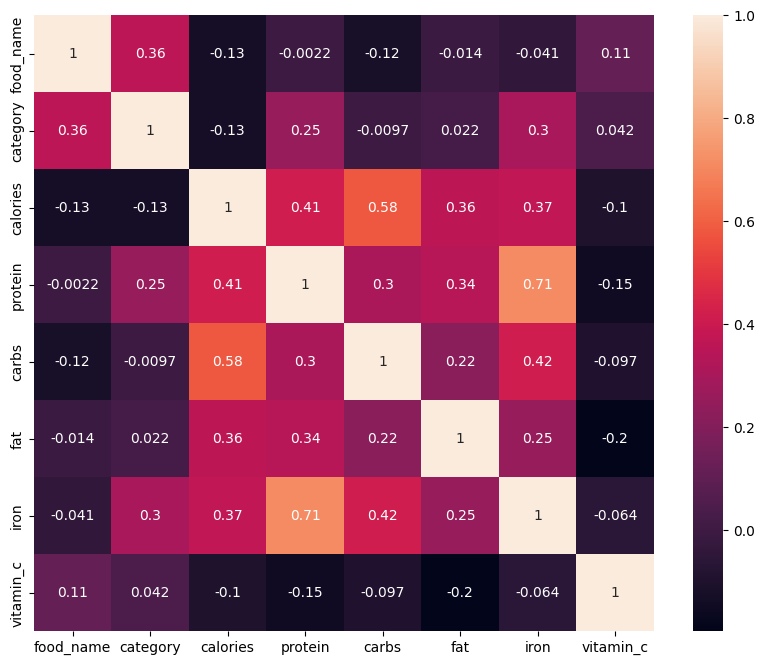

In [8]:
#heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

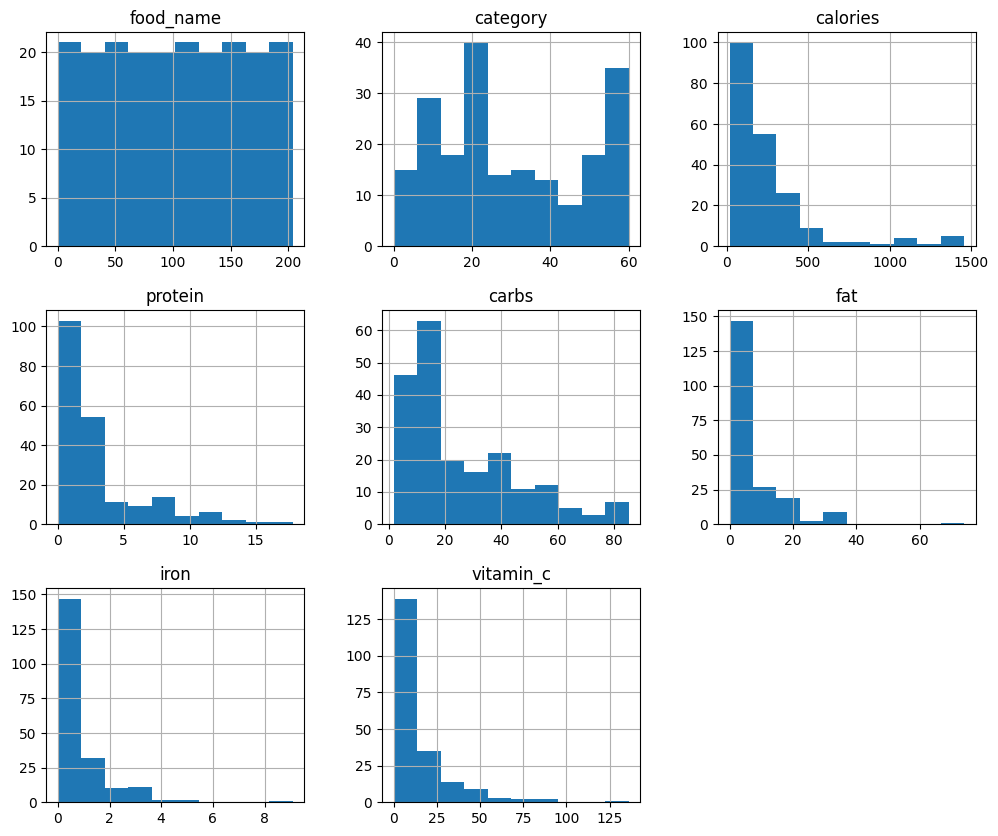

In [9]:
#histogram
df.hist(figsize=(12,10))
plt.show()

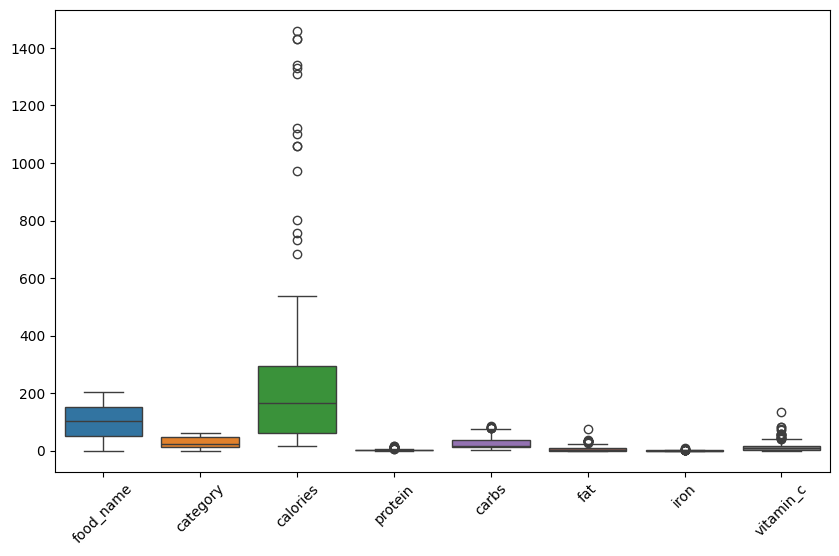

In [10]:
#boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

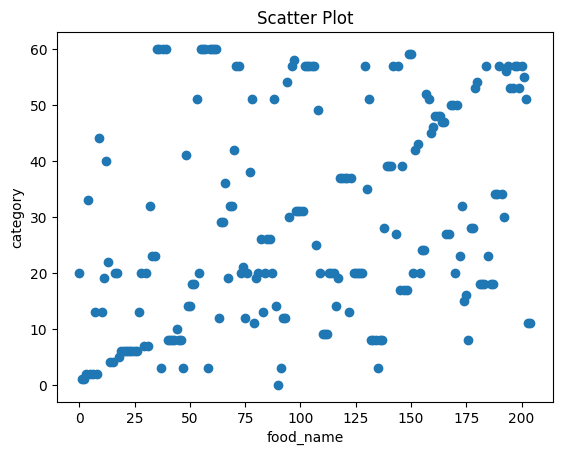

In [11]:
#scatter plot
plt.scatter(df.iloc[:,0], df.iloc[:,1])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Scatter Plot")
plt.show()

In [12]:
X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

In [13]:
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

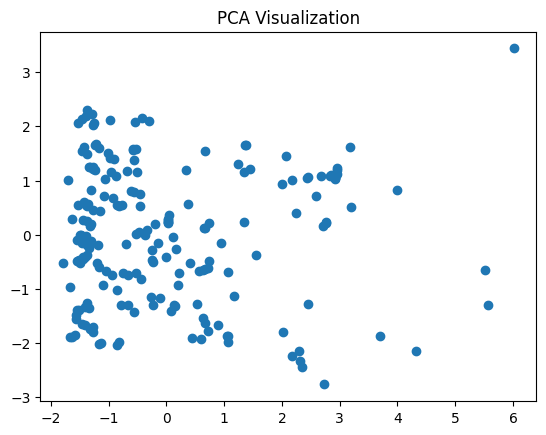

In [14]:
#pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.show()

In [15]:
X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

# FORCE conversion
y = (y > y.mean()).astype(int)

print(y.unique())   # check karo

[0 1]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [17]:
#linear regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Executed")

Linear Regression Executed


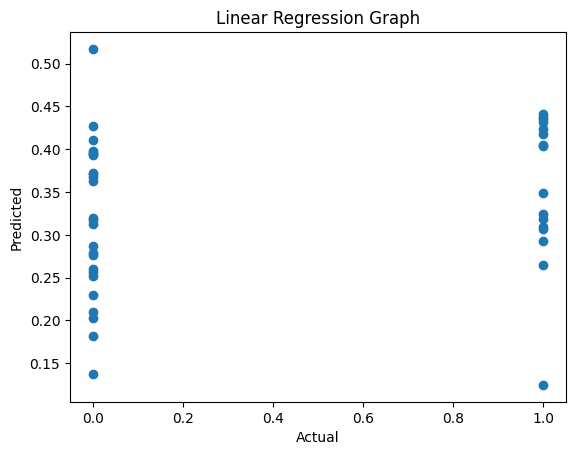

In [18]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Graph")
plt.show()

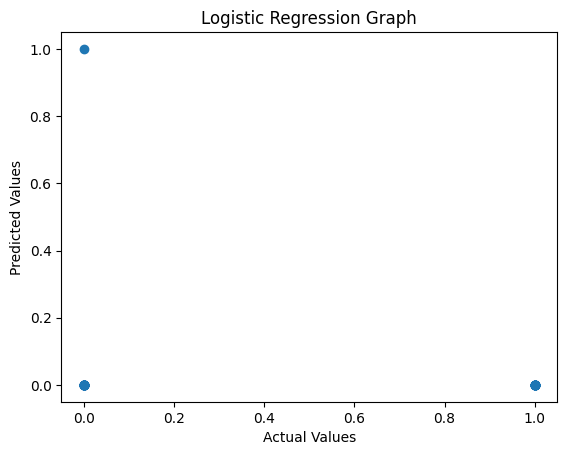

In [19]:
# Logistic Regression model alag se
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

# Graph
plt.scatter(y_test, y_pred_log)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Logistic Regression Graph")
plt.show()

In [20]:
#models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "LDA": LinearDiscriminantAnalysis()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.2f}")

Logistic Regression: 0.59
Decision Tree: 0.61
Random Forest: 0.80
LDA: 0.59


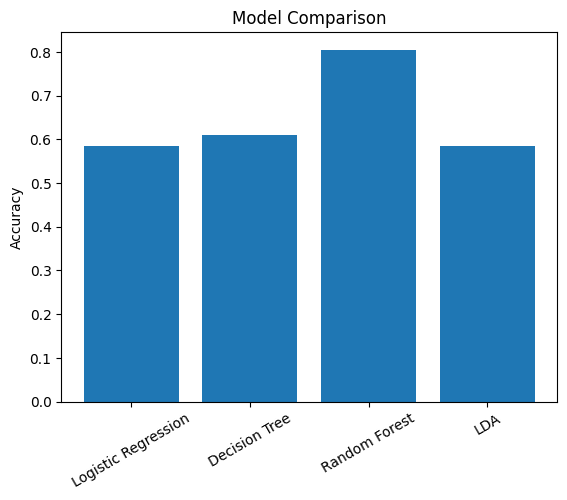

In [21]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()